# Análise exploratória dos dados do dataset MovieLens 100k

Esse dataset apresenta 100 mil avaliações de 600 usuários para quase 9000 filmes. Ele também possui 3600 tags de aplicação.

## Importação de dependências e dados

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = "../data/raw/ml-latest-small"

In [3]:
movies = pd.read_csv(os.path.join(data_path, "movies.csv"))
ratings = pd.read_csv(os.path.join(data_path, "ratings.csv"))

## Análises iniciais

### Movies

**Objetivo:** conhecer a estrutura da tabela `movies`, verificando suas dimensões, tipos de dados e possíveis valores inconsistentes.

In [4]:
movies.shape

(9742, 3)

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [7]:
movies.duplicated().sum()

np.int64(0)

Tabela `movies` possui 9742 registros. 3 variáveis:
- `movieId`
- `title`
- `genres`

Não foram identificados valores ausentes ou registros duplicados. 
Observa-se também que os gêneros são armazenados em uma string separada por `|`, 
o que vai exigir tratamento posteriormente.

#### Analisando Gêneros

In [8]:
movies["genres"] = movies["genres"].str.split("|")

In [9]:
genres = movies.explode("genres")
genre_counts = genres["genres"].value_counts()

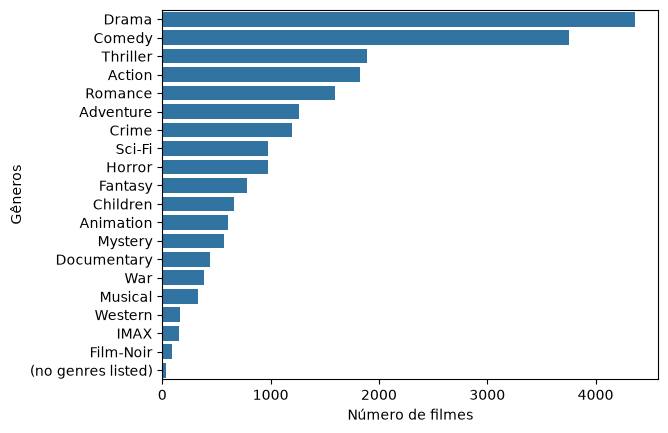

In [10]:
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
)

plt.xlabel("Número de filmes")
plt.ylabel("Gêneros")
plt.show()

### Ratings

**Objetivo:** Analisar a estrutura e a qualidade da tabela `ratings`, verificando suas dimensões, consistência e o comportamento das avaliações realizadas pelos usuários. Também serão exploradas características como a distribuição das notas, quantidade média de avaliações por usuário e por filme, e possíveis padrôes temporais.

In [11]:
ratings.shape

(100836, 4)

In [12]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [13]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [14]:
ratings.duplicated().sum()

np.int64(0)

#### Estatísticas das avaliações

In [15]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [16]:
ratings['rating'].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

<Axes: xlabel='rating', ylabel='count'>

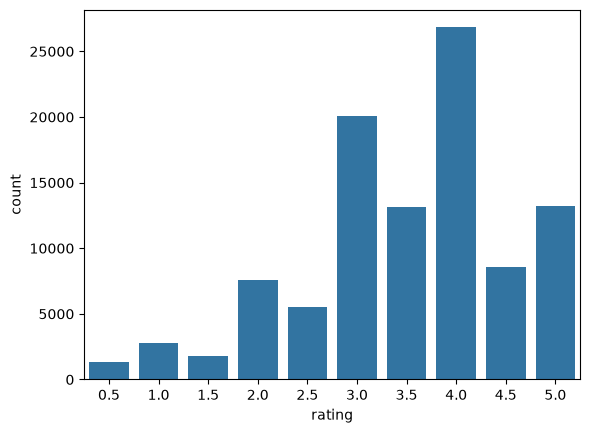

In [17]:
sns.countplot(data=ratings, x="rating")

#### Quantidades de notas por usuário

In [18]:
ratings.groupby("userId").size().describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

<Axes: ylabel='Count'>

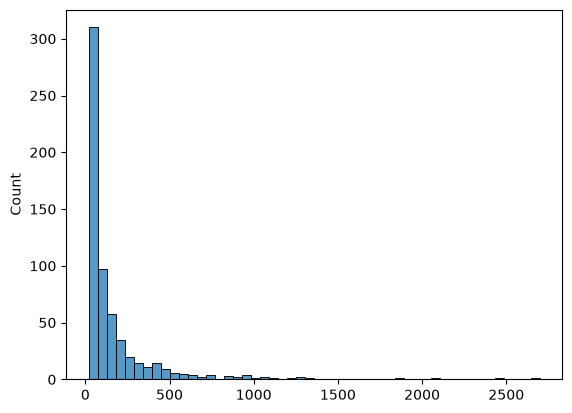

In [19]:
sns.histplot(ratings.groupby("userId").size(), bins=50)

A média de avaliações por usuário é relativamente alta (165 filmes por usuários). Além disso, também temos um desvio padrão alto, o que indica que temos uma variabilidade bem grande de perfis de usuários, em termos de quanto filmes eles avaliam. No histograma, podemos ver que há um pico muito grande de usuários com cerca de 20 avaliações, mas ainda conseguimos ver bins relativamente destacados até por volta das 750 avaliações.

#### Quantidades de notas por filmes

In [20]:
ratings.groupby("movieId").size().describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

<Axes: ylabel='Count'>

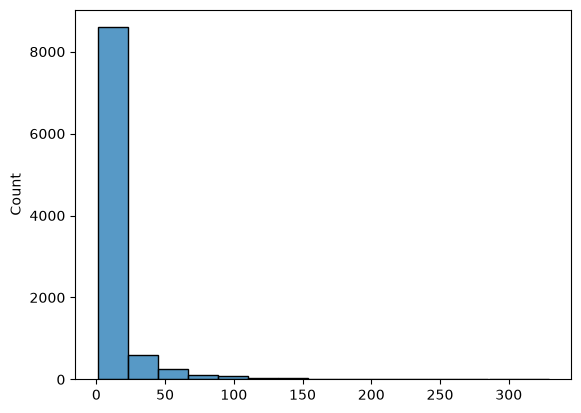

In [21]:
sns.histplot(ratings.groupby("movieId").size(), bins=15)

Podemos ver que não se forma uma cauda longa. Grande parte dos filmes tem pouquíssimas avaliações enquanto poucos filmes possuem muitas.

#### Evolução temporal

In [22]:
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit='s')

In [23]:
ratings["year"] = ratings["date"].dt.year

In [24]:
ratings["date"].dt.year.value_counts().sort_index()

date
1996     6040
1997     1916
1998      507
1999     2439
2000    10061
2001     3922
2002     3478
2003     4014
2004     3279
2005     5813
2006     4059
2007     7114
2008     4351
2009     4158
2010     2301
2011     1690
2012     4656
2013     1664
2014     1439
2015     6616
2016     6703
2017     8198
2018     6418
Name: count, dtype: int64

In [25]:
ratings["year"].value_counts().sort_index()

year
1996     6040
1997     1916
1998      507
1999     2439
2000    10061
2001     3922
2002     3478
2003     4014
2004     3279
2005     5813
2006     4059
2007     7114
2008     4351
2009     4158
2010     2301
2011     1690
2012     4656
2013     1664
2014     1439
2015     6616
2016     6703
2017     8198
2018     6418
Name: count, dtype: int64

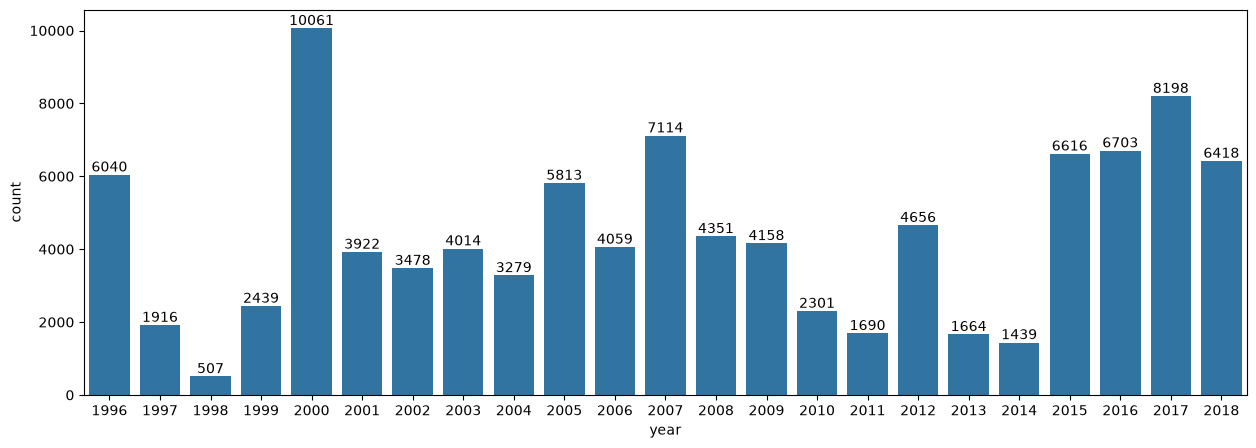

In [26]:
plt.figure(figsize=(15,5))
ax = sns.countplot(ratings, x="year")
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

In [27]:
ratings.groupby("year").size().describe()

count       23.000000
mean      4384.173913
std       2418.734167
min        507.000000
25%       2370.000000
50%       4059.000000
75%       6229.000000
max      10061.000000
dtype: float64

Podemos ver que a distribuição de avaliações de filmes ao longo dos anos não tem uma tendência muito clara.

#### Filmes mais avaliados

In [28]:
ratings.groupby("movieId").size().sort_values(ascending=False).head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
dtype: int64

In [29]:
top_movies = ratings.groupby("movieId").size()

top_movies = top_movies.reset_index(name="n")

top_movies.merge(movies, on="movieId").sort_values(by="n", ascending=False).head(10)

,movieId,n,title,genres
314,356,329,Forrest Gump (1994),"[Comedy, Drama, Romance, War]"
277,318,317,"Shawshank Redemption, The (1994)","[Crime, Drama]"
257,296,307,Pulp Fiction (1994),"[Comedy, Crime, Drama, Thriller]"
510,593,279,"Silence of the Lambs, The (1991)","[Crime, Horror, Thriller]"
1938,2571,278,"Matrix, The (1999)","[Action, Sci-Fi, Thriller]"
224,260,251,Star Wars: Episode IV - A New Hope (1977),"[Action, Adventure, Sci-Fi]"
418,480,238,Jurassic Park (1993),"[Action, Adventure, Sci-Fi, Thriller]"
97,110,237,Braveheart (1995),"[Action, Drama, War]"
507,589,224,Terminator 2: Judgment Day (1991),"[Action, Sci-Fi]"
461,527,220,Schindler's List (1993),"[Drama, War]"


#### Filmes mais bem avaliados

In [30]:
movie_stats = ratings.groupby("movieId").agg(
                media=("rating", "mean"),
                n=("rating", "count")
            )

In [31]:
movie_stats.merge(movies, on="movieId").sort_values(by="media", ascending=False).head(10)

,movieId,media,n,title,genres
87,99,5.0,2,Heidi Fleiss: Hollywood Madam (1995),[Documentary]
6903,64501,5.0,1,Che: Part Two (2008),"[Drama, War]"
1036,1349,5.0,1,Vampire in Venice (Nosferatu a Venezia) (Nosfe...,[Horror]
7583,86721,5.0,1,Idiots and Angels (2008),"[Animation, Drama, Fantasy]"
7582,86668,5.0,1,Louis Theroux: Law & Disorder (2008),[Documentary]
5015,7815,5.0,1,True Stories (1986),"[Comedy, Musical]"
2235,2972,5.0,1,Red Sorghum (Hong gao liang) (1987),"[Drama, War]"
2232,2969,5.0,1,"Man and a Woman, A (Un homme et une femme) (1966)","[Drama, Romance]"
9370,163925,5.0,1,"Wings, Legs and Tails (1986)","[Animation, Comedy]"
7618,87834,5.0,1,My Life as McDull (Mak dau goo si) (2001),"[Animation, Comedy, Drama]"


In [32]:
movie_stats.query("n >= 100").merge(movies, on="movieId").sort_values(by="media", ascending=False).head(10)

,movieId,media,n,title,genres
25,318,4.429022,317,"Shawshank Redemption, The (1994)","[Crime, Drama]"
58,858,4.289062,192,"Godfather, The (1972)","[Crime, Drama]"
103,2959,4.272936,218,Fight Club (1999),"[Action, Crime, Drama, Thriller]"
76,1221,4.259690,129,"Godfather: Part II, The (1974)","[Crime, Drama]"
133,48516,4.252336,107,"Departed, The (2006)","[Crime, Drama, Thriller]"
74,1213,4.250000,126,Goodfellas (1990),"[Crime, Drama]"
59,912,4.240000,100,Casablanca (1942),"[Drama, Romance]"
134,58559,4.238255,149,"Dark Knight, The (2008)","[Action, Crime, Drama, IMAX]"
8,50,4.237745,204,"Usual Suspects, The (1995)","[Crime, Mystery, Thriller]"
68,1197,4.232394,142,"Princess Bride, The (1987)","[Action, Adventure, Comedy, Fantasy, Romance]"


### Relação entre tables

#### Matriz usuário x filme

In [33]:
matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

In [34]:
sparsity = (
    matrix.isna().sum().sum() 
    / matrix.size
)
print(f"Esparsidade: {sparsity}")

Esparsidade: 0.9830003169443864


## Verificação de integridade

In [35]:
# Todos os filmes de 'ratings' estão no dataframe 'movies'?
all_movies_id_exist = ratings['movieId'].isin(movies['movieId']).all()
print(f"Todos os id's de filmes em ratings existem em movies? {all_movies_id_exist}")

Todos os id's de filmes em ratings existem em movies? True


In [36]:
all_movies_are_rated = movies['movieId'].isin(ratings['movieId']).all()
movies_rated = movies['movieId'].isin(ratings['movieId']).sum()

print(f"Todos os filmes possuem ratings? {all_movies_are_rated}")
print(f"Quantidade de filmes com ratings: {movies_rated}")
print(f"Quantidade total de filmes: {movies["movieId"].nunique()}")

Todos os filmes possuem ratings? False
Quantidade de filmes com ratings: 9724
Quantidade total de filmes: 9742


In [37]:
n_users = ratings["userId"].nunique()
n_movies = movies["movieId"].nunique()
n_ratings = len(ratings)

print(f"Número de filmes:   {n_movies}")
print(f"Número de ratings:  {n_ratings}")
print(f"Número de usuários: {n_users}")

Número de filmes:   9742
Número de ratings:  100836
Número de usuários: 610
